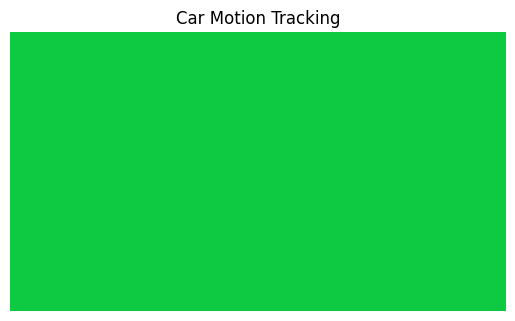

✅ Tracking Stopped


In [1]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Load video (use FULL PATH)
cap = cv2.VideoCapture("C:/Users/lenovo/Desktop/IPCV/Videos/car.mp4")

ret, frame1 = cap.read()
if not ret:
    print("❌ Error: Cannot read video")
    exit()

# Convert first frame
prev_gray = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
prev_gray = cv2.GaussianBlur(prev_gray, (11, 11), 0)

print("🚗 Car Motion Tracking Started...")

while True:
    ret, frame2 = cap.read()
    if not ret:
        break

    # Convert current framepl
    gray = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (11, 11), 0)

    # Frame difference
    diff = cv2.absdiff(prev_gray, gray)

    # Threshold
    _, thresh = cv2.threshold(diff, 20, 255, cv2.THRESH_BINARY)

    # Dilation
    thresh = cv2.dilate(thresh, None, iterations=2)

    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)

    # Draw bounding boxes
    for c in contours:
        if cv2.contourArea(c) > 1000:
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(frame2, (x, y), (x + w, y + h),
                          (0, 255, 0), 2)

    # Display using matplotlib (Jupyter)
    frame_rgb = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    plt.imshow(frame_rgb)
    plt.title("Car Motion Tracking")
    plt.axis('off')
    display(plt.gcf())
    plt.close()

    # Update previous frame
    prev_gray = gray

# Release resources
cap.release()
print("✅ Tracking Stopped")